# Dynamic Model in Levels

In [32]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

import doubleml as dml

from utils.utils_data2 import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)

# Get a colorblind-friendly palette
palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "..\output\R2"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Confidence Level: 90.0%


In [33]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../data/{dataframe_name}_val.zip")

columns_to_drop = [
    'Q_t-2',
    'P_bb_t-2',
    'REVIEW_COUNT_t-2',
    'RATING_t-2',
    'pred_ml_l_lag_1',
    'pred_ml_m_lag_1',
]


df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [category for category in df_full_val['subcat_aggregated'].unique()]
all_time_steps = sorted([str(date) for date in df_full_val['date'].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'Cars & Race Cars', 'Trains & Trams', 'Train Sets', 'Trucks', 'Tractors', 'Race Tracks', 'Airplanes', 'Motor Vehicles', 'Vehicle Playsets', 'Skateboards']
All time steps: ['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'REVIEW_COUNT_t-1', 'RATING_t-1', 'Delta_Q_t', 'Delta_P_bb_t',
       'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff', 'pred_ml_m_diff',
       'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1'],
      dtype='object', length=342)

In [34]:
print(dataframe_name)

dataset_txt_only_False_embeddings_True


In [35]:
print(df_full_val.shape)
print(df_full_train.shape)

(38041, 342)
(38146, 342)


In [36]:
df_full_val.isna().sum()

ASIN                    0
date                    0
index                   0
Q_t                     0
PRICE                   0
                       ..
pred_ml_m               0
pred_ml_l_diff          0
pred_ml_m_diff          0
pred_ml_l_diff_lag_1    0
pred_ml_m_diff_lag_1    0
Length: 342, dtype: int64

In [37]:
df_full_train["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [38]:
df_full_val["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [39]:
df_full_train["ASIN"].nunique()

3717

In [40]:
df_full_val["ASIN"].nunique()

3708

In [41]:
from datetime import datetime

date_objects = [datetime.strptime(date, '%Y-%m-%d') for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [(date_objects[i+1] - date_objects[i]).days for i in range(len(date_objects) - 1)]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Names

In [42]:
n_lags = 1

outcome = ["Q_t"]
base_treatment = ["P_bb_t"]
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = (
    dummy_subcat_names
    + dummy_time_steps
    + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]
)
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
]

add_controls_to_scale = [
    "RATING",
    "REVIEW_COUNT",
]

controls_pca = ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
controls_similarities = [
    'similarity_cluster_0',
    'similarity_cluster_1',
    'similarity_cluster_2',
    'similarity_cluster_3',
    'similarity_cluster_4'
]

embeddings = [f"emb_{i}" for i in range(256)]

controls_to_scale = cont_controls + add_controls_to_scale

additional_controls = (
    cont_controls
    + dummy_controls
)

In [43]:
dummy_controls

['Cars & Race Cars',
 'Trains & Trams',
 'Train Sets',
 'Trucks',
 'Tractors',
 'Race Tracks',
 'Airplanes',
 'Motor Vehicles',
 'Vehicle Playsets',
 'Skateboards',
 '2023-04-24',
 '2023-05-22',
 '2023-06-19',
 '2023-07-17',
 '2023-08-14',
 '2023-09-11',
 '2023-10-09',
 '2023-11-06',
 '2023-12-04',
 '2024-01-01',
 '2024-01-29',
 'Lightning Deals: Upcoming Deal',
 'Buy Box: Is FBA']

In [44]:
additional_controls

['RATING_t-1',
 'REVIEW_COUNT_t-1',
 'New Offer Count: Current',
 'Count of retrieved live offers: New, FBA',
 'Count of retrieved live offers: New, FBM',
 'Cars & Race Cars',
 'Trains & Trams',
 'Train Sets',
 'Trucks',
 'Tractors',
 'Race Tracks',
 'Airplanes',
 'Motor Vehicles',
 'Vehicle Playsets',
 'Skateboards',
 '2023-04-24',
 '2023-05-22',
 '2023-06-19',
 '2023-07-17',
 '2023-08-14',
 '2023-09-11',
 '2023-10-09',
 '2023-11-06',
 '2023-12-04',
 '2024-01-01',
 '2024-01-29',
 'Lightning Deals: Upcoming Deal',
 'Buy Box: Is FBA']

## Interactions & CATE Basis

In [45]:
basis_vars = controls_similarities + lag_1_vars
df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=lag_1_vars,
    degree=1
)
df_basis.head()

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,0.305280,0.463601,-0.461880,0.463422,0.457113,-0.620049,-0.080700
1,1.0,0.272505,0.653600,-0.461880,0.463422,0.457113,-0.620049,-0.080700
2,1.0,0.036240,0.687961,-0.461695,0.459950,0.457477,-0.622177,-0.072107
3,1.0,0.025283,0.636881,-0.461695,0.459950,0.457477,-0.622177,-0.072107
4,1.0,-0.051370,0.556816,-0.461695,0.459950,0.457477,-0.622177,-0.072107


In [46]:
df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val,
    df_basis=df_basis,
    cols_to_interact=["Q_t-1", "P_bb_t-1"])

print(f"Interactions: {interaction_vars}")
df_interact_val.columns

Interactions: ['interaction_Q_t-1_intercept', 'interaction_Q_t-1_Q_t-1', 'interaction_Q_t-1_P_bb_t-1', 'interaction_Q_t-1_similarity_cluster_0', 'interaction_Q_t-1_similarity_cluster_1', 'interaction_Q_t-1_similarity_cluster_2', 'interaction_Q_t-1_similarity_cluster_3', 'interaction_Q_t-1_similarity_cluster_4', 'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1', 'interaction_P_bb_t-1_P_bb_t-1', 'interaction_P_bb_t-1_similarity_cluster_0', 'interaction_P_bb_t-1_similarity_cluster_1', 'interaction_P_bb_t-1_similarity_cluster_2', 'interaction_P_bb_t-1_similarity_cluster_3', 'interaction_P_bb_t-1_similarity_cluster_4']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'interaction_Q_t-1_similarity_cluster_3',
       'interaction_Q_t-1_similarity_cluster_4',
       'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1',
       'interaction_P_bb_t-1_P_bb_t-1',
       'interaction_P_bb_t-1_similarity_cluster_0',
       'interaction_P_bb_t-1_similarity_cluster_1',
       'interaction_P_bb_t-1_similarity_cluster_2',
       'interaction_P_bb_t-1_similarity_cluster_3',
       'interaction_P_bb_t-1_similarity_cluster_4'],
      dtype='object', length=358)

## Average Effect

In [47]:
df_dynamic = df_interact_val.copy()

### Linear Models

In [48]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [49]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.0027
          coef  std err        t  P>|t|   [5.0%  95.0%]
const  -10.756    0.104 -103.858  0.000 -10.926 -10.586
P_bb_t  -0.111    0.033   -3.384  0.001  -0.164  -0.057


,lower,upper,coef
P_bb_t,-0.164462,-0.056884,-0.110673


In [50]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.8835
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -0.677    0.034  -19.935    0.0 -0.733  -0.621
P_bb_t   -0.690    0.040  -17.248    0.0 -0.756  -0.624
Q_t-1     0.936    0.003  321.411    0.0  0.931   0.941
P_bb_t-1  0.678    0.040   16.995    0.0  0.613   0.744


In [51]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.8884
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -1.346    0.060  -22.322  0.000 -1.445  -1.247
P_bb_t   -0.657    0.040  -16.626  0.000 -0.722  -0.592
Q_t-1     0.862    0.005  157.814  0.000  0.853   0.871
P_bb_t-1  0.600    0.039   15.305  0.000  0.536   0.665
emb_0     0.195    0.123    1.591  0.112 -0.007   0.397
...         ...      ...      ...    ...    ...     ...
emb_251   0.027    0.109    0.251  0.802 -0.152   0.207
emb_252   0.185    0.111    1.669  0.095  0.003   0.366
emb_253   0.054    0.100    0.534  0.593 -0.111   0.219
emb_254  -0.104    0.093   -1.120  0.263 -0.258   0.049
emb_255  -0.349    0.102   -3.427  0.001 -0.517  -0.182

[260 rows x 6 columns]


In [52]:
ci_linear_base_lagged_add_controls = estimate_linear_model(controls=lag_1_vars + additional_controls)

Adjusted R^2: 0.8929
                                           coef  std err        t  P>|t|  \
const                                    -0.962    0.051  -18.978  0.000   
P_bb_t                                   -0.746    0.039  -18.956  0.000   
Q_t-1                                     0.925    0.003  279.493  0.000   
P_bb_t-1                                  0.722    0.039   18.383  0.000   
RATING_t-1                                0.030    0.007    4.621  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    8.670  0.000   
New Offer Count: Current                 -0.001    0.001   -1.625  0.104   
Count of retrieved live offers: New, FBA  0.005    0.001    3.398  0.001   
Count of retrieved live offers: New, FBM -0.004    0.001   -3.797  0.000   
Cars & Race Cars                          0.020    0.006    3.371  0.001   
Trains & Trams                            0.052    0.014    3.754  0.000   
Train Sets                                0.032    0.008    4.069  

In [53]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(controls=lag_1_vars + additional_controls + embeddings)

Adjusted R^2: 0.8968
             coef  std err        t  P>|t|  [5.0%  95.0%]
const      -1.541    0.072  -21.359  0.000 -1.660  -1.422
P_bb_t     -0.712    0.039  -18.364  0.000 -0.776  -0.649
Q_t-1       0.858    0.006  152.447  0.000  0.849   0.868
P_bb_t-1    0.654    0.039   16.937  0.000  0.591   0.718
RATING_t-1  0.029    0.007    3.852  0.000  0.016   0.041
...           ...      ...      ...    ...    ...     ...
emb_251     0.066    0.107    0.618  0.537 -0.110   0.241
emb_252     0.111    0.109    1.020  0.308 -0.068   0.290
emb_253     0.118    0.100    1.188  0.235 -0.045   0.282
emb_254    -0.058    0.092   -0.630  0.529 -0.209   0.093
emb_255    -0.329    0.099   -3.330  0.001 -0.492  -0.167

[288 rows x 6 columns]


In [54]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(controls=lag_1_vars + controls_similarities + additional_controls)

Adjusted R^2: 0.8959
                                           coef  std err        t  P>|t|  \
const                                    -1.400    0.066  -21.088  0.000   
P_bb_t                                   -0.723    0.039  -18.725  0.000   
Q_t-1                                     0.878    0.005  167.971  0.000   
P_bb_t-1                                  0.680    0.038   17.699  0.000   
similarity_cluster_0                     -0.136    0.094   -1.446  0.148   
similarity_cluster_1                     -0.570    0.112   -5.109  0.000   
similarity_cluster_2                     -0.958    0.198   -4.840  0.000   
similarity_cluster_3                     -1.115    0.225   -4.953  0.000   
similarity_cluster_4                     -0.499    0.086   -5.821  0.000   
RATING_t-1                                0.024    0.007    3.648  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    9.364  0.000   
New Offer Count: Current                  0.000    0.001    0.076  

In [55]:
ci_linear_interactions = estimate_linear_model(controls=interaction_vars + controls_similarities + additional_controls)

Adjusted R^2: 0.8964
                                             coef  std err       t  P>|t|  \
const                                      -1.942    0.480  -4.043  0.000   
P_bb_t                                     -0.727    0.039 -18.698  0.000   
interaction_Q_t-1_intercept                 0.595    0.042  14.033  0.000   
interaction_Q_t-1_Q_t-1                    -0.010    0.005  -2.093  0.036   
interaction_Q_t-1_P_bb_t-1                 -0.048    0.002 -21.256  0.000   
interaction_Q_t-1_similarity_cluster_0      0.467    0.140   3.330  0.001   
interaction_Q_t-1_similarity_cluster_1     -0.320    0.126  -2.549  0.011   
interaction_Q_t-1_similarity_cluster_2     -1.529    0.334  -4.584  0.000   
interaction_Q_t-1_similarity_cluster_3     -1.664    0.370  -4.497  0.000   
interaction_Q_t-1_similarity_cluster_4     -0.386    0.099  -3.887  0.000   
interaction_P_bb_t-1_intercept             -0.149    0.012 -12.260  0.000   
interaction_P_bb_t-1_Q_t-1                  0.087    0.

In [56]:
ci_hedonic_time_fixed = estimate_linear_model(controls=additional_controls)

Adjusted R^2: 0.2213
                                            coef  std err       t  P>|t|  \
const                                    -11.961    0.233 -51.298  0.000   
P_bb_t                                    -0.225    0.031  -7.254  0.000   
RATING_t-1                                 0.222    0.047   4.710  0.000   
REVIEW_COUNT_t-1                           0.000    0.000   5.015  0.000   
New Offer Count: Current                  -0.015    0.006  -2.599  0.009   
Count of retrieved live offers: New, FBA   0.056    0.013   4.217  0.000   
Count of retrieved live offers: New, FBM  -0.033    0.008  -4.285  0.000   
Cars & Race Cars                           0.259    0.057   4.513  0.000   
Trains & Trams                             0.456    0.131   3.473  0.001   
Train Sets                                 0.422    0.077   5.454  0.000   
Trucks                                     0.464    0.064   7.291  0.000   
Tractors                                   0.399    0.131   3.042  

In [57]:
dummy_subcat_names_wo_baseline = [d for d in dummy_subcat_names if d not in dummy_baselines]

time_varying_controls = cont_controls + dummy_subcat_names_wo_baseline + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]

time_varying_interaction_cols = []
for t in dummy_time_steps:
    for c in time_varying_controls:
        col_name = f"{c} x {t}"
        df_dynamic[col_name] = df_dynamic[c] * df_dynamic[t]
        time_varying_interaction_cols.append(col_name)

time_varying_interaction_cols

C:\Users\Work\AppData\Local\Temp\ipykernel_21116\3145919612.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dynamic[col_name] = df_dynamic[c] * df_dynamic[t]
C:\Users\Work\AppData\Local\Temp\ipykernel_21116\3145919612.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dynamic[col_name] = df_dynamic[c] * df_dynamic[t]
C:\Users\Work\AppData\Local\Temp\ipykernel_21116\3145919612.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

['RATING_t-1 x 2023-03-27',
 'REVIEW_COUNT_t-1 x 2023-03-27',
 'New Offer Count: Current x 2023-03-27',
 'Count of retrieved live offers: New, FBA x 2023-03-27',
 'Count of retrieved live offers: New, FBM x 2023-03-27',
 'Cars & Race Cars x 2023-03-27',
 'Trains & Trams x 2023-03-27',
 'Train Sets x 2023-03-27',
 'Trucks x 2023-03-27',
 'Tractors x 2023-03-27',
 'Race Tracks x 2023-03-27',
 'Airplanes x 2023-03-27',
 'Motor Vehicles x 2023-03-27',
 'Vehicle Playsets x 2023-03-27',
 'Skateboards x 2023-03-27',
 'Lightning Deals: Upcoming Deal x 2023-03-27',
 'Buy Box: Is FBA x 2023-03-27',
 'RATING_t-1 x 2023-04-24',
 'REVIEW_COUNT_t-1 x 2023-04-24',
 'New Offer Count: Current x 2023-04-24',
 'Count of retrieved live offers: New, FBA x 2023-04-24',
 'Count of retrieved live offers: New, FBM x 2023-04-24',
 'Cars & Race Cars x 2023-04-24',
 'Trains & Trams x 2023-04-24',
 'Train Sets x 2023-04-24',
 'Trucks x 2023-04-24',
 'Tractors x 2023-04-24',
 'Race Tracks x 2023-04-24',
 'Airplanes

In [58]:
ci_hedonic_time_varying = estimate_linear_model(controls=time_varying_interaction_cols)

Adjusted R^2: 0.2086
                                               coef  std err        t  P>|t|  \
const                                       -10.584    0.102 -104.100  0.000   
P_bb_t                                       -0.215    0.031   -6.999  0.000   
RATING_t-1 x 2023-03-27                      -0.098    0.019   -5.230  0.000   
REVIEW_COUNT_t-1 x 2023-03-27                 0.000    0.000   14.122  0.000   
New Offer Count: Current x 2023-03-27        -0.027    0.007   -3.726  0.000   
...                                             ...      ...      ...    ...   
Motor Vehicles x 2024-01-29                   0.656    0.149    4.393  0.000   
Vehicle Playsets x 2024-01-29                 0.134    0.103    1.294  0.196   
Skateboards x 2024-01-29                     -0.147    0.067   -2.190  0.029   
Lightning Deals: Upcoming Deal x 2024-01-29   1.666    0.095   17.607  0.000   
Buy Box: Is FBA x 2024-01-29                  0.201    0.047    4.317  0.000   

                  

In [59]:
ci_linear_base_lagged['model'] = 'Linear lagged'
ci_linear_embeddings['model'] = 'Linear lagged_and_embeddings'
ci_linear_base_lagged_add_controls['model'] = 'Linear lagged_and_add_controls'
ci_linear_base_lagged_add_controls_emb['model'] = 'Linear lagged_and_add_controls_and_emb'
ci_linear_base_lagged_add_controls_sim['model'] = 'Linear lagged_and_add_controls_and_sim'
ci_linear_interactions['model'] = 'Linear interactions'
ci_hedonic_time_fixed['model'] = 'Hedonic time fixed effects'
ci_hedonic_time_varying['model'] = 'Hedonic time varying coefficients'

df_base = pd.concat([
    ci_linear_base_lagged,
    ci_linear_embeddings,
    ci_linear_base_lagged_add_controls,
    ci_linear_base_lagged_add_controls_emb,
    ci_linear_base_lagged_add_controls_sim,
    ci_linear_interactions,
    ci_hedonic_time_fixed,
    ci_hedonic_time_varying,
], ignore_index=True)

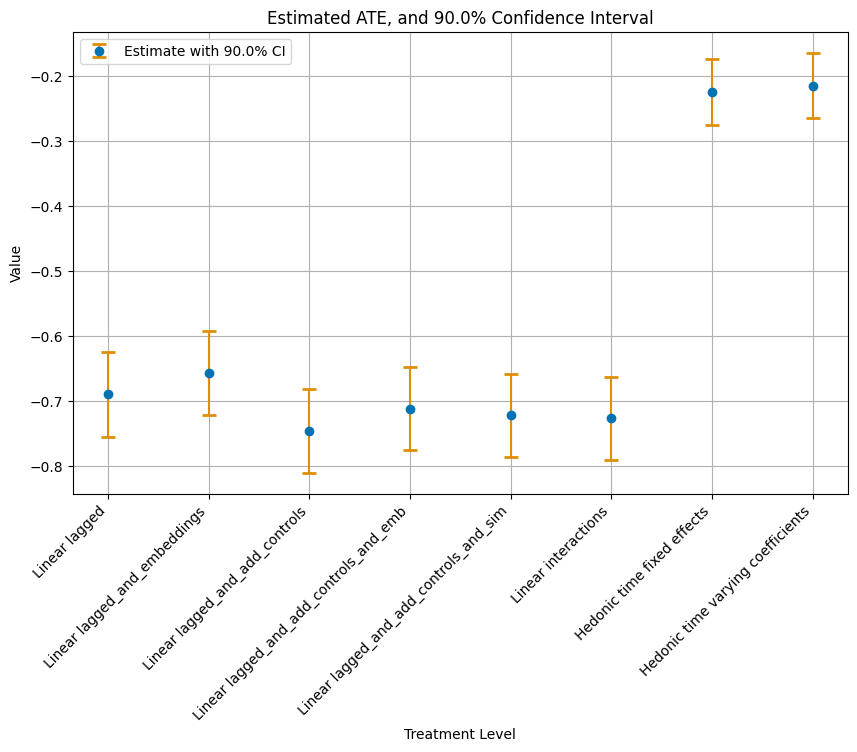

In [60]:

# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(df_base['model'], df_base['coef'],
             yerr=[df_base['coef'] - df_base['lower'], df_base['upper'] - df_base['coef']],
             fmt='o', capsize=5, capthick=2, ecolor=palette[1], color=palette[0], label=f'Estimate with {round(confidence_level*100, 1)}% CI', zorder=2)

plt.title(f'Estimated ATE, and {round(confidence_level*100, 1)}% Confidence Interval')
plt.xlabel('Treatment Level')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f'hedonic_linear_ate_estimates.png'))
plt.show()